<h1>Модель прогнозирования фрода</h1>

## Поля

Поля Transactions Fraud Datasets:<br>

- transaction_id Уникальный идентификатор транзакции
- customer_id Идентификатор клиента
- card_id Идентификатор карты
- transaction_date Дата и время транзакции
- amount Сумма транзакции
- merchant Магазин / получатель платежа
- transaction_type Тип транзакции (покупка, снятие и т.д.)
- location Место совершения транзакции
- fraud Флаг мошенничества (1 / 0)

ссылка https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets


In [1]:
import pandas as pd
import json
import numpy as np

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transaction_df = pd.read_csv("data/transactions_fraud/transactions_data.csv").head(1000000)
users_df = pd.read_csv("data/transactions_fraud/users_data.csv")
cards_df = pd.read_csv("data/transactions_fraud/cards_data.csv")

In [3]:
transaction_df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,8674648,2010-10-23 12:45:00,502,2018,$20.00,Swipe Transaction,27092,Warren,PA,16365.0,4829,NaN
999996,8674649,2010-10-23 12:45:00,1029,3346,$8.37,Swipe Transaction,58110,Mulberry,FL,33860.0,5813,NaN
999997,8674650,2010-10-23 12:45:00,1105,2036,$71.97,Swipe Transaction,20561,Mission,TX,78572.0,5912,NaN
999998,8674651,2010-10-23 12:45:00,1285,3216,$13.46,Swipe Transaction,21461,Annandale,VA,22003.0,5813,NaN


In [4]:
users_df

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,32,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,$23550,$48010,$87837,703,3
1996,1944,62,65,1957,11,Female,2 Elm Drive,38.95,-84.54,$24218,$49378,$104480,740,4
1997,185,47,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,$15175,$30942,$71066,779,3
1998,1007,66,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,$25336,$54654,$27241,618,1


In [5]:
cards_df

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


## merge


In [6]:
transaction_df = transaction_df.rename(columns={"id": "transaction_id"})
users_df = users_df.rename(columns={"id": "client_id_users"})
cards_df = cards_df.rename(columns={"id": "card_id_cards"})
cards_df = cards_df.rename(columns={"client_id": "client_id_cards"})

In [7]:
df = pd.merge(transaction_df, users_df, left_on="client_id", right_on="client_id_users", how="left")
df = pd.merge(df, cards_df, left_on="card_id", right_on="card_id_cards", how="left")

## Преобразование и создание переменных


### Целевая переменная


структура json в датасете: { "target": { "id": "Yes/No", ... } }


In [8]:
with open("data/transactions_fraud/train_fraud_labels.json", "r") as f:
    fraud = json.load(f)["target"]

fraud_df = pd.DataFrame.from_dict(fraud, orient="index", columns=["fraud"])
fraud_df.index = fraud_df.index.astype(int)
fraud_df["fraud"] = (fraud_df["fraud"] == "Yes").astype(int)

df = pd.merge(df, fraud_df[["fraud"]], left_on="transaction_id", right_index=True, how="left")

print(df["fraud"].value_counts())
print(f"Fraud rate: {df['fraud'].mean():.4%}")
print(f"na: {df['fraud'].isna().sum()}")

fraud
0.0    667793
1.0      2127
Name: count, dtype: int64
Fraud rate: 0.3175%
na: 330080


In [9]:
df

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,fraud
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,5497590243197280,07/2022,306,YES,2,$55,05/2008,2008,No,0.0
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,5175842699412235,12/2024,438,YES,1,$9100,09/2005,2015,No,0.0
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,5874992802287595,05/2020,256,YES,1,$14802,01/2006,2008,No,0.0
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,...,5346827663529174,10/2024,54,NO,2,$37634,05/2004,2006,No,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,4354185735186651,01/2020,120,YES,1,$19113,07/2009,2014,No,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,8674648,2010-10-23 12:45:00,502,2018,$20.00,Swipe Transaction,27092,Warren,PA,16365.0,...,6910816000642923,03/2020,845,YES,2,$7900,03/2001,2004,No,NaN
999996,8674649,2010-10-23 12:45:00,1029,3346,$8.37,Swipe Transaction,58110,Mulberry,FL,33860.0,...,5044033311360211,04/2012,274,YES,2,$12760,06/2007,2009,No,NaN
999997,8674650,2010-10-23 12:45:00,1105,2036,$71.97,Swipe Transaction,20561,Mission,TX,78572.0,...,5772409732789359,04/2020,218,YES,2,$9027,03/2002,2015,No,NaN
999998,8674651,2010-10-23 12:45:00,1285,3216,$13.46,Swipe Transaction,21461,Annandale,VA,22003.0,...,5607772753172564,12/2023,609,YES,2,$20933,06/2000,2014,No,0.0


In [10]:
with pd.option_context('display.max_columns', None):
    display(df.describe(include="all"))

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,client_id_users,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_id_cards,client_id_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,fraud
count,1.000000e+06,1000000,1000000.000000,1000000.000000,1000000,1000000,1000000.000000,1000000,890869,884923.00000,1000000.000000,15623,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000,1000000.000000,1000000.000000,1000000,1000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000,1.000000e+06,1000000,1000000.000000,1000000,1000000.000000,1000000,1000000,1000000.000000,1000000,669920.000000
unique,NaN,333598,NaN,NaN,34774,2,NaN,6914,120,NaN,NaN,18,NaN,NaN,NaN,NaN,NaN,2,1126,NaN,NaN,1041,1112,1064,NaN,NaN,NaN,NaN,4,3,NaN,180,NaN,2,NaN,1875,194,NaN,1,NaN
top,NaN,2010-05-09 09:49:00,NaN,NaN,$80.00,Swipe Transaction,NaN,ONLINE,CA,NaN,NaN,Insufficient Balance,NaN,NaN,NaN,NaN,NaN,Female,772 Fifth Boulevard,NaN,NaN,$0,$34456,$0,NaN,NaN,NaN,NaN,Mastercard,Debit,NaN,02/2020,NaN,YES,NaN,$10600,02/2010,NaN,No,NaN
freq,NaN,16,NaN,NaN,10475,890869,NaN,109131,108522,NaN,NaN,9678,NaN,NaN,NaN,NaN,NaN,508082,3970,NaN,NaN,5544,3970,51401,NaN,NaN,NaN,NaN,536352,614504,NaN,28479,NaN,902438,NaN,7701,20815,NaN,1000000,NaN
mean,8.074077e+06,NaN,1031.404634,3371.447930,NaN,NaN,47804.559379,NaN,NaN,51612.02763,5563.689269,NaN,1031.404634,54.861015,66.483883,1964.317259,6.591686,NaN,NaN,37.360979,-91.675855,NaN,NaN,NaN,714.120816,3.892441,3371.447930,1031.404634,NaN,NaN,4.794616e+15,NaN,498.511107,NaN,1.534085,NaN,NaN,2010.912212,NaN,0.003175
std,3.461477e+05,NaN,582.522773,1681.930546,NaN,NaN,25764.304200,NaN,NaN,29406.86513,872.610520,NaN,582.522773,15.478096,3.595894,15.460787,3.601905,NaN,NaN,5.135063,16.272542,NaN,NaN,NaN,65.556217,1.570036,1681.930546,582.522773,NaN,NaN,1.359418e+15,NaN,285.652965,NaN,0.516351,NaN,NaN,2.995955,NaN,0.056258
min,7.475327e+06,NaN,0.000000,0.000000,NaN,NaN,2.000000,NaN,NaN,1012.00000,1711.000000,NaN,0.000000,27.000000,53.000000,1918.000000,1.000000,NaN,NaN,21.300000,-158.180000,NaN,NaN,NaN,488.000000,1.000000,0.000000,0.000000,NaN,NaN,3.001055e+14,NaN,0.000000,NaN,1.000000,NaN,NaN,2002.000000,NaN,0.000000
25%,7.774100e+06,NaN,515.000000,2239.000000,NaN,NaN,25887.000000,NaN,NaN,28645.00000,5300.000000,NaN,515.000000,43.000000,65.000000,1955.000000,3.000000,NaN,NaN,33.850000,-97.370000,NaN,NaN,NaN,684.000000,3.000000,2239.000000,515.000000,NaN,NaN,4.475381e+15,NaN,256.000000,NaN,1.000000,NaN,NaN,2009.000000,NaN,0.000000
50%,8.073848e+06,NaN,1077.000000,3431.000000,NaN,NaN,46284.000000,NaN,NaN,48036.00000,5499.000000,NaN,1077.000000,52.000000,66.000000,1967.000000,7.000000,NaN,NaN,38.350000,-86.780000,NaN,NaN,NaN,717.000000,4.000000,3431.000000,1077.000000,NaN,NaN,5.125930e+15,NaN,502.000000,NaN,2.000000,NaN,NaN,2010.000000,NaN,0.000000
75%,8.373562e+06,NaN,1534.000000,4718.000000,NaN,NaN,67570.000000,NaN,NaN,78130.00000,5812.000000,NaN,1534.000000,64.000000,68.000000,1976.000000,10.000000,NaN,NaN,41.130000,-80.160000,NaN,NaN,NaN,756.000000,5.000000,4718.000000,1534.000000,NaN,NaN,5.572602e+15,NaN,741.000000,NaN,2.000000,NaN,NaN,2013.000000,NaN,0.000000


### Обработка пропусков


In [11]:
df.isna().sum().sort_values(ascending=False).head(10)

errors            984377
fraud             330080
zip               115077
merchant_state    109131
transaction_id         0
date                   0
client_id              0
card_id                0
merchant_city          0
merchant_id            0
dtype: int64

In [12]:
df = df.dropna(subset=['fraud'])
print(df['fraud'].value_counts())


fraud
0.0    667793
1.0      2127
Name: count, dtype: int64


### Удаление id


удаляем<br>
id, т.к. высокая кардиальность и "запоминание" моделью<br>
card_on_dark_web - одно уникальное значение<br>
birth - то же, что age


In [13]:
df = df.drop(columns=[
    'transaction_id', 'client_id', 'card_id', 'client_id_users', 'client_id_cards', 'card_id_cards', 'card_number', 'cvv',
    'card_on_dark_web', 'birth_year', 'birth_month'
])

In [14]:
df.isna().sum().sort_values(ascending=False).head(10)

errors            659423
zip                76977
merchant_state     73001
amount                 0
date                   0
merchant_city          0
merchant_id            0
use_chip               0
mcc                    0
current_age            0
dtype: int64

In [15]:
with pd.option_context('display.max_columns', None):
    display(df)

,date,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,current_age,retirement_age,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,fraud
0,2010-01-01 00:01:00,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,30,67,Female,594 Mountain View Street,46.80,-100.76,$23679,$48277,$110153,740,4,Mastercard,Debit (Prepaid),07/2022,YES,2,$55,05/2008,2008,0.0
1,2010-01-01 00:02:00,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,48,67,Male,604 Pine Street,40.80,-91.12,$18076,$36853,$112139,834,5,Mastercard,Credit,12/2024,YES,1,$9100,09/2005,2015,0.0
2,2010-01-01 00:02:00,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,49,65,Male,2379 Forest Lane,33.18,-117.29,$16894,$34449,$36540,686,3,Mastercard,Debit,05/2020,YES,1,$14802,01/2006,2008,0.0
4,2010-01-01 00:06:00,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,51,69,Male,166 River Drive,38.86,-76.60,$33529,$68362,$96182,711,2,Visa,Debit,01/2020,YES,1,$19113,07/2009,2014,0.0
5,2010-01-01 00:07:00,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN,47,65,Female,14780 Plum Lane,40.84,-73.87,$25537,$52065,$98613,828,5,Mastercard,Debit (Prepaid),03/2014,YES,1,$89,01/2008,2015,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999989,2010-10-23 12:43:00,$107.14,Swipe Transaction,61195,Grand Forks,ND,58201.0,5541,NaN,45,71,Male,70 Tenth Boulevard,47.91,-97.07,$23910,$48755,$37315,777,8,Visa,Debit,11/2022,YES,1,$30314,10/2005,2007,0.0
999991,2010-10-23 12:44:00,$32.13,Swipe Transaction,75779,Tampa,FL,33610.0,7995,NaN,80,67,Female,80471 Eighth Street,27.95,-82.48,$13254,$13596,$352,684,4,Mastercard,Debit,11/2021,YES,1,$11749,10/1998,2008,0.0
999994,2010-10-23 12:44:00,$0.11,Swipe Transaction,14528,Meridian,MS,39301.0,5499,NaN,57,66,Male,126 Valley Drive,32.32,-90.20,$11061,$22556,$43260,645,4,Visa,Debit,09/2020,YES,2,$13514,06/2009,2018,0.0
999998,2010-10-23 12:45:00,$13.46,Swipe Transaction,21461,Annandale,VA,22003.0,5813,NaN,68,53,Female,6723 Maple Street,38.83,-77.21,$30622,$65298,$18684,524,2,Mastercard,Debit,12/2023,YES,2,$20933,06/2000,2014,0.0


удаление $ из стоимостей


In [16]:
df['amount'] = df['amount'].str[1:].apply(pd.to_numeric)
df['per_capita_income'] = df['per_capita_income'].str[1:].apply(pd.to_numeric)
df['yearly_income'] = df['yearly_income'].str[1:].apply(pd.to_numeric)
df['total_debt'] = df['total_debt'].str[1:].apply(pd.to_numeric)
df['credit_limit'] = df['credit_limit'].str[1:].apply(pd.to_numeric)

по дате


In [17]:
# date
df['transaction_year'] = df['date'].str.slice(stop=4).apply(pd.to_numeric)
df['transaction_month'] = df['date'].str.slice(start=5, stop=7).apply(pd.to_numeric)
df['transaction_day'] = df['date'].str.slice(start=8, stop=10).apply(pd.to_numeric)
df['transaction_hour'] = df['date'].str.slice(start=11, stop=13).apply(pd.to_numeric)
df['transaction_minute'] = df['date'].str.slice(start=14, stop=16).apply(pd.to_numeric)
# df = df.drop('date', axis=1)

# expires
df['expires_year'] = df['expires'].str.slice(start=3).apply(pd.to_numeric)
df['expires_month'] = df['expires'].str.slice(stop=2).apply(pd.to_numeric)
df = df.drop('expires', axis=1)

# acct_open_date
df['acct_open_date_year'] = df['acct_open_date'].str.slice(start=3).apply(pd.to_numeric)
df['acct_open_date_month'] = df['acct_open_date'].str.slice(stop=2).apply(pd.to_numeric)
df = df.drop('acct_open_date', axis=1)

улица


In [18]:
%%capture

street_reg = r'^\w+\s+'
df['street'] = df['address'].str.replace(street_reg, '', regex=True)
df['city_street'] = df['merchant_city'] + ' ' + df['street']
df = df.drop(columns=['address', 'street'])

### Обработка категориальных


In [19]:
low_card_cols = ['errors', 'use_chip', 'gender', 'card_brand', 'card_type', 'has_chip']
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True, dtype=int)


high_card_cols = ['merchant_id', 'merchant_state', 'merchant_city', 'mcc', 'city_street']

for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq)

df = df.drop(columns=high_card_cols)

In [20]:
with pd.option_context('display.max_columns', None):
    display(df.describe(include="all"))

,date,amount,zip,current_age,retirement_age,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,num_cards_issued,credit_limit,year_pin_last_changed,fraud,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_minute,expires_year,expires_month,acct_open_date_year,acct_open_date_month,"errors_Bad CVV,Insufficient Balance","errors_Bad CVV,Technical Glitch",errors_Bad Card Number,"errors_Bad Card Number,Bad CVV","errors_Bad Card Number,Bad Expiration","errors_Bad Card Number,Insufficient Balance",errors_Bad Expiration,"errors_Bad Expiration,Insufficient Balance","errors_Bad Expiration,Technical Glitch",errors_Bad PIN,"errors_Bad PIN,Insufficient Balance","errors_Bad PIN,Technical Glitch",errors_Bad Zipcode,errors_Insufficient Balance,"errors_Insufficient Balance,Technical Glitch",errors_Technical Glitch,use_chip_Swipe Transaction,gender_Male,card_brand_Discover,card_brand_Mastercard,card_brand_Visa,card_type_Debit,card_type_Debit (Prepaid),has_chip_YES,merchant_id_freq,merchant_state_freq,merchant_city_freq,mcc_freq,city_street_freq
count,669920,669920.000000,592943.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.0,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,669920.000000,596919.000000,669920.000000,669920.000000,669920.000000
unique,293915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2010-02-07 16:19:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,43.625908,51619.970071,54.837009,66.486813,37.363219,-91.676923,23967.254517,46594.057134,57032.757084,714.156159,3.891529,1.534380,15316.663027,2010.913248,0.003175,2010.0,5.444298,15.382156,12.411089,29.618445,2020.749209,6.426018,2005.912115,6.364376,0.000001,0.000001,0.000509,0.000003,0.000003,0.000013,0.000433,0.000003,0.000001,0.002445,0.000022,0.000009,0.000085,0.009665,0.000013,0.001994,0.891030,0.491817,0.025422,0.536352,0.367725,0.614485,0.068565,0.902511,0.012826,0.046230,0.013196,0.061392,0.000511
std,NaN,84.435275,29419.240550,15.462580,3.596970,5.135226,16.268699,12049.467646,24713.979293,51507.407845,65.521743,1.568968,0.516191,11981.319701,2.995195,0.056258,0.0,2.805104,8.681312,5.097512,17.315931,3.214312,3.428762,3.240070,3.437504,0.001222,0.001222,0.022556,0.001728,0.001728,0.003665,0.020801,0.001728,0.001222,0.049387,0.004732,0.002993,0.009224,0.097836,0.003665,0.044613,0.311601,0.499933,0.157404,0.498677,0.482186,0.486717,0.252713,0.296623,0.015843,0.036909,0.033540,0.041570,0.000468
min,NaN,-500.000000,1013.000000,28.000000,53.000000,21.300000,-158.180000,0.000000,1.000000,0.000000,488.000000,1.000000,1.000000,0.000000,2002.000000,0.000000,2010.0,1.000000,1.000000,0.000000,0.000000,2010.000000,1.000000,1991.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00

## Корреляция


### с целевой переменной


In [21]:
df["fraud"] = df["fraud"].astype(int)

corr_with_target = df.corr(numeric_only=True)["fraud"].drop("fraud").sort_values(key=abs, ascending=False)

print(corr_with_target.head(20))

use_chip_Swipe Transaction                    -0.144352
merchant_city_freq                             0.143960
mcc_freq                                      -0.056160
amount                                         0.049531
transaction_hour                              -0.033404
merchant_id_freq                              -0.032207
merchant_state_freq                           -0.022773
errors_Bad Card Number                         0.016372
city_street_freq                              -0.011223
errors_Bad Expiration                          0.010306
credit_limit                                  -0.007702
errors_Bad Card Number,Insufficient Balance    0.007032
card_type_Debit                               -0.006706
year_pin_last_changed                         -0.006542
card_type_Debit (Prepaid)                      0.006527
longitude                                     -0.006437
card_brand_Discover                            0.006393
per_capita_income                             -0

### межколлинеарность


In [22]:
corr_matrix = df.corr(numeric_only=True)

corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={0: "correlation", "level_0": "feature_1", "level_1": "feature_2"})
)

corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
top_pairs = corr_pairs.sort_values("abs_corr", ascending=False).head(20)

display(top_pairs)

,feature_1,feature_2,correlation,abs_corr
2690,merchant_city_freq,use_chip_Swipe Transaction,-0.998599,0.998599
377,yearly_income,per_capita_income,0.950343,0.950343
266,longitude,zip,-0.852766,0.852766
2375,card_brand_Visa,card_brand_Mastercard,-0.820236,0.820236
642,credit_limit,per_capita_income,0.620645,0.620645
643,credit_limit,yearly_income,0.576313,0.576313
431,total_debt,yearly_income,0.494107,0.494107
430,total_debt,per_capita_income,0.428370,0.428370
2751,mcc_freq,merchant_id_freq,0.420627,0.420627
426,total_debt,current_age,-0.398625,0.398625


In [23]:
# plt.figure(figsize=(16, 14))
# sns.heatmap(df.drop('date', axis=1).corr(), annot=False, cmap="coolwarm")
# plt.show()

удаляем

- merchant_city_freq, т.к. способ оплаты swipe сильно коррелирует с большими городами
- per_capita_income, т.к. yearly - личный доход клиента, а не средний в регионе, что меньше влияет на транзакцию
- zip, т.к. есть latitude / longitude (числовые, zip - по факту категориальный, хотя записывается как число)

будем руководствоваться правилом большого пальца: 0,95 < |корр|


In [24]:
df = df.drop(columns=["merchant_city_freq"])
df = df.drop(columns=["per_capita_income"])
df = df.drop(columns=["zip"])

## Распределение


распределение целевой переменной


fraud
0    667793
1      2127
Name: count, dtype: int64

Доли:
fraud
0    0.996825
1    0.003175
Name: proportion, dtype: float64


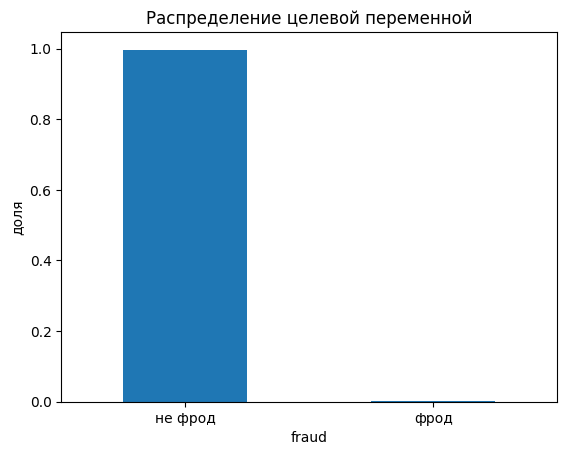

In [25]:
print(df["fraud"].value_counts())
print("\nДоли:")
print(df["fraud"].value_counts(normalize=True))

df["fraud"].value_counts(normalize=True).plot(kind="bar")
plt.title("Распределение целевой переменной")
plt.xticks([0, 1], ["не фрод", "фрод"], rotation=0)
plt.ylabel("доля")
plt.show()

распределение amount транзакций


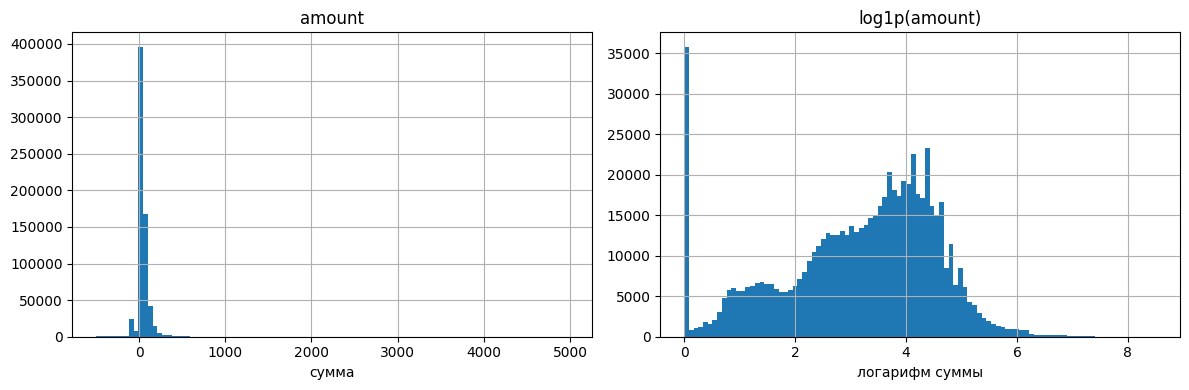

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["amount"].hist(bins=100, ax=axes[0])
axes[0].set_title("amount")
axes[0].set_xlabel("сумма")

np.log1p(df["amount"].clip(lower=0)).hist(bins=100, ax=axes[1])
axes[1].set_title("log1p(amount)")
axes[1].set_xlabel("логарифм суммы")

plt.tight_layout()
plt.show()

In [27]:
print(f"amount <= 0: {(df['amount'] <= 0).sum()}")
print(f"amount <= 1: {(df['amount'] <= 1).sum()}")
print(df['amount'].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))


amount <= 0: 35528
amount <= 1: 47930
count    669920.000000
mean         43.625908
std          84.435275
min        -500.000000
1%          -97.000000
5%          -52.000000
10%           1.670000
50%          29.550000
90%         107.120000
95%         148.270500
99%         327.000000
max        4978.450000
Name: amount, dtype: float64


есть отрицательные суммы


In [28]:
df['amount_abs'] = df['amount'].abs()
df['amount_sign'] = (df['amount'] > 0).astype(int)
df['amount_log'] = np.log1p(df['amount_abs'])


часы транзакций


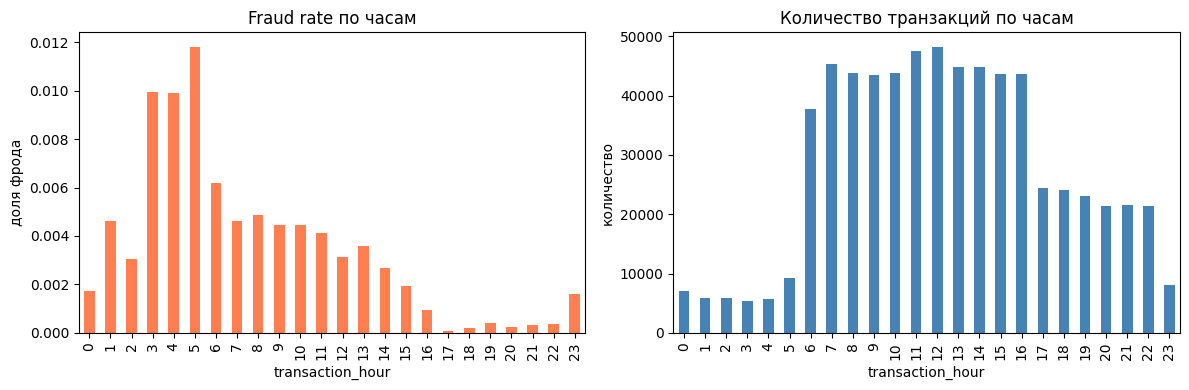

In [29]:
hourly_fraud = df.groupby("transaction_hour")["fraud"].agg(["mean", "count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hourly_fraud["mean"].plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Fraud rate по часам")
axes[0].set_ylabel("доля фрода")

hourly_fraud["count"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Количество транзакций по часам")
axes[1].set_ylabel("количество")

plt.tight_layout()
plt.show()

## Определение числовых и категориальных признаков


In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'fraud']
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric columns ({len(numeric_cols)}):')
print(numeric_cols)
print(f'\nCategorical columns ({len(categorical_cols)}):')
print(categorical_cols)

df[numeric_cols].nunique().sort_values()

C:\Users\fedos\AppData\Local\Temp\ipykernel_19136\1966553632.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Numeric columns (52):
['amount', 'current_age', 'retirement_age', 'latitude', 'longitude', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'num_cards_issued', 'credit_limit', 'year_pin_last_changed', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_minute', 'expires_year', 'expires_month', 'acct_open_date_year', 'acct_open_date_month', 'errors_Bad CVV,Insufficient Balance', 'errors_Bad CVV,Technical Glitch', 'errors_Bad Card Number', 'errors_Bad Card Number,Bad CVV', 'errors_Bad Card Number,Bad Expiration', 'errors_Bad Card Number,Insufficient Balance', 'errors_Bad Expiration', 'errors_Bad Expiration,Insufficient Balance', 'errors_Bad Expiration,Technical Glitch', 'errors_Bad PIN', 'errors_Bad PIN,Insufficient Balance', 'errors_Bad PIN,Technical Glitch', 'errors_Bad Zipcode', 'errors_Insufficient Balance', 'errors_Insufficient Balance,Technical Glitch', 'errors_Technical Glitch', 'use_chip_Swipe Transaction', 'gender_Male',

transaction_year                                    1
errors_Bad Card Number,Bad Expiration               2
errors_Bad Card Number,Insufficient Balance         2
errors_Bad Expiration                               2
errors_Bad Expiration,Insufficient Balance          2
errors_Bad PIN,Insufficient Balance                 2
errors_Bad Expiration,Technical Glitch              2
errors_Bad PIN                                      2
errors_Bad Card Number,Bad CVV                      2
errors_Bad CVV,Insufficient Balance                 2
errors_Bad Card Number                              2
errors_Bad CVV,Technical Glitch                     2
errors_Insufficient Balance,Technical Glitch        2
errors_Insufficient Balance                         2
errors_Bad Zipcode                                  2
errors_Bad PIN,Technical Glitch                     2
card_brand_Discover                                 2
gender_Male                                         2
amount_sign                 

## Выбросы


18 признаков


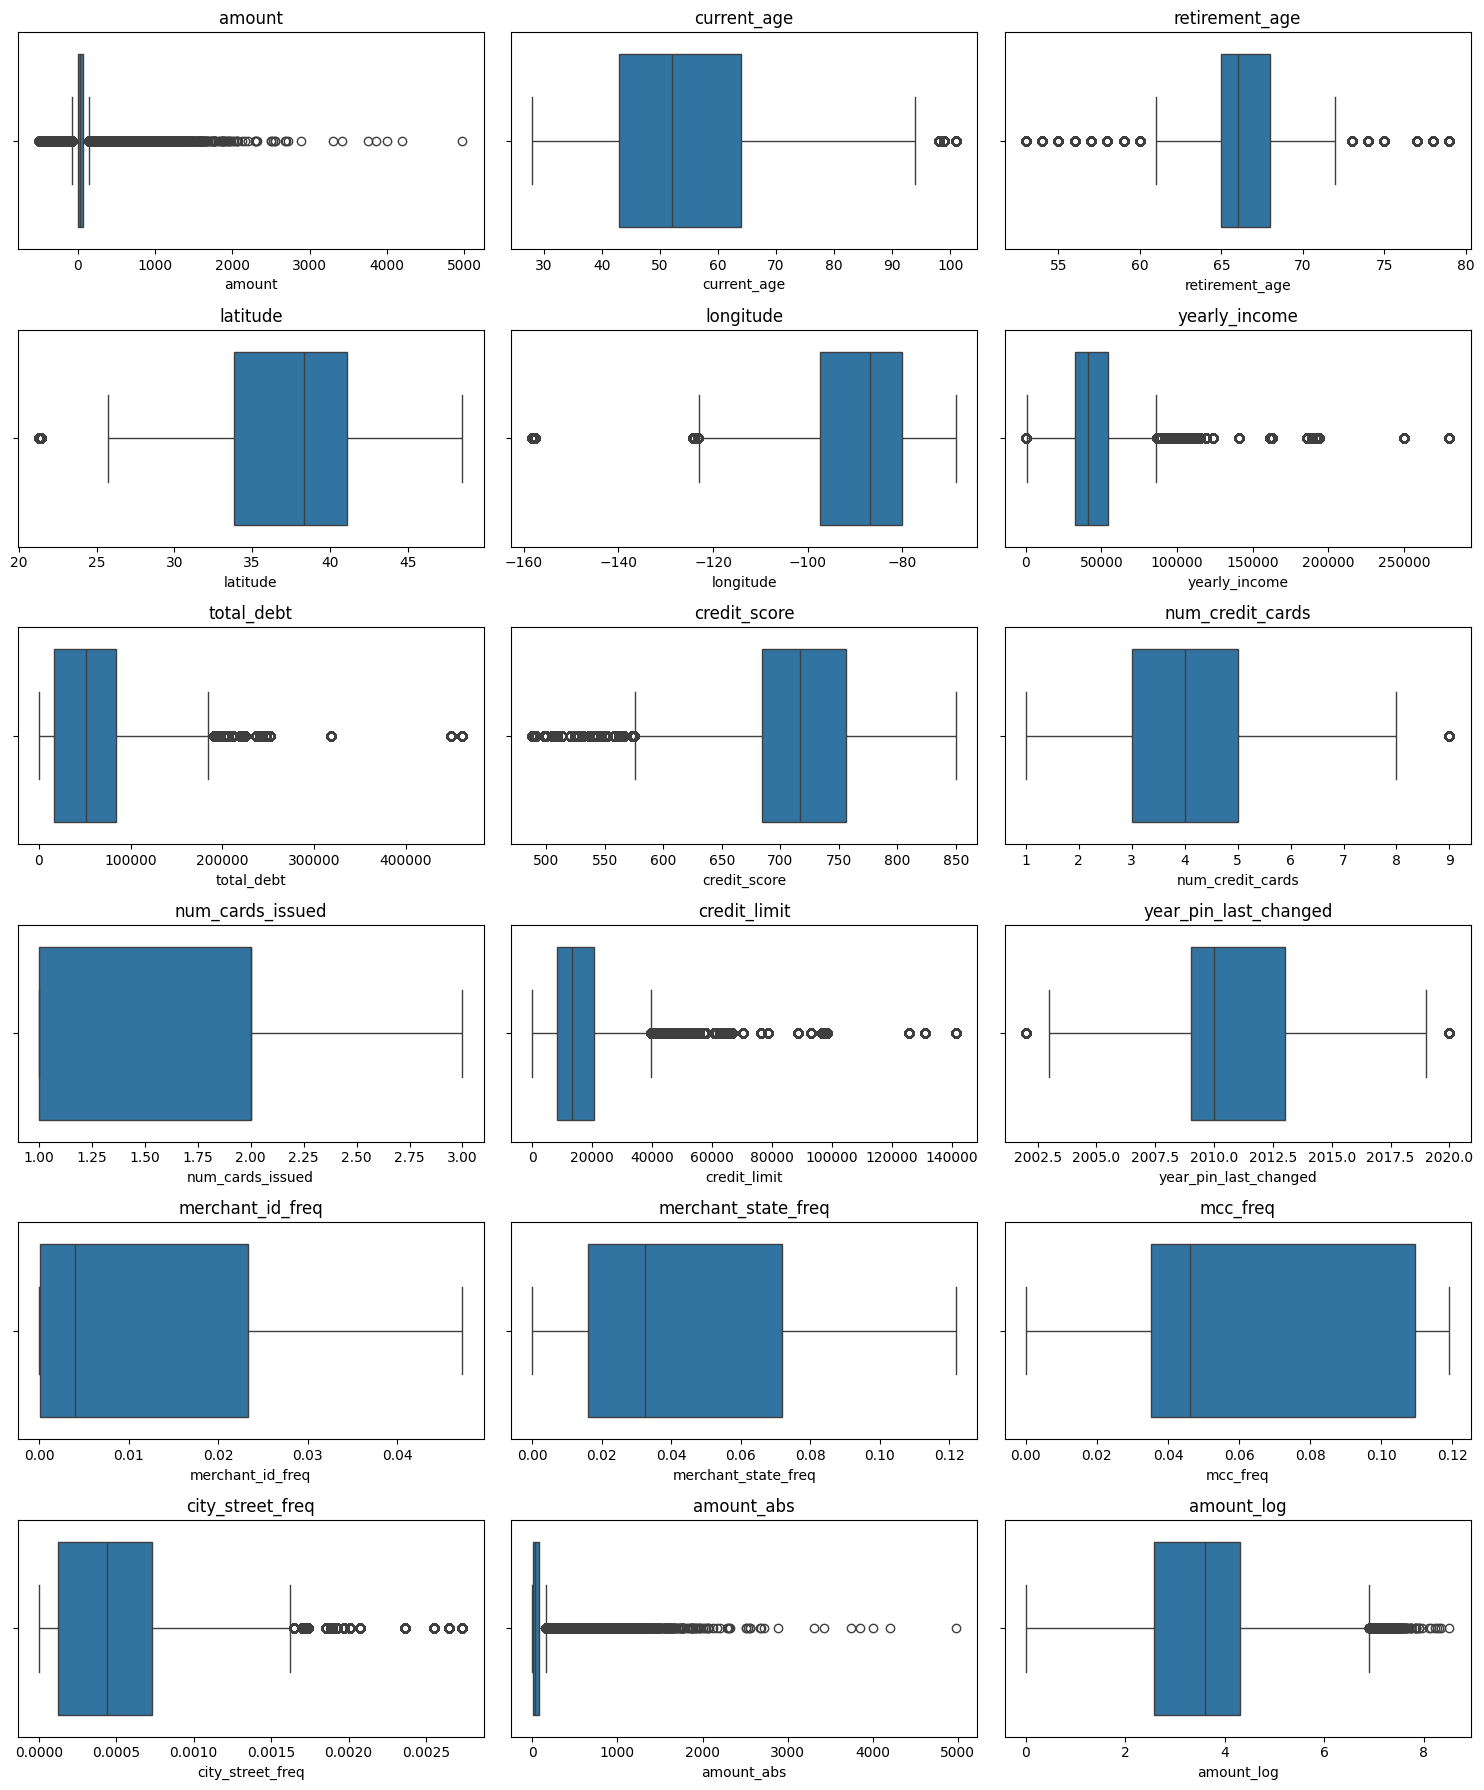

In [31]:
exclude = [
    'transaction_year', 'transaction_month', 'transaction_day',
    'transaction_hour', 'transaction_minute',
    'expires_year', 'expires_month',
    'acct_open_date_year', 'acct_open_date_month',
    'amount_sign'
]

exclude += [c for c in numeric_cols if c.startswith((
    'errors_', 'use_chip_', 'gender_', 'card_brand_', 'card_type_', 'has_chip_'
))]

plot_cols = [c for c in numeric_cols if c not in exclude]
print(f"{len(plot_cols)} признаков")

n_cols = 3
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [32]:
df = df.drop(columns=['amount']) # удалена, тк повторяет log

In [33]:
df[df['credit_score'] < 600]['fraud'].mean()

np.float64(0.002777994132460991)

In [34]:
for col in ['amount_log', 'credit_score', 'yearly_income', 'credit_limit']:
    print(col, df[df[col] > df[col].quantile(0.99)]['fraud'].mean())


amount_log 0.02299193789190803
credit_score nan
yearly_income 0.001423374980230903
credit_limit 0.0029051987767584097


Крупные суммы явно чаще фродовые


<Axes: xlabel='amount_log_decile'>

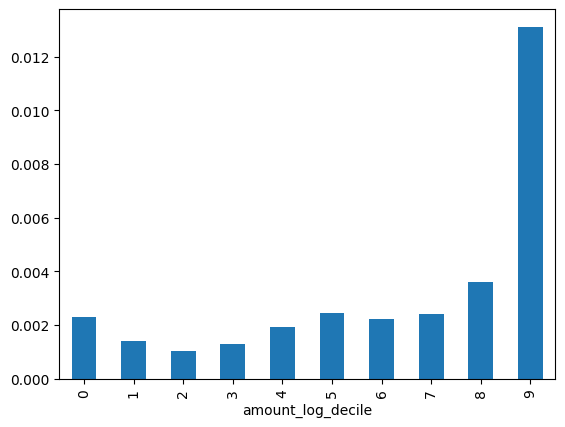

In [35]:
df['amount_log_decile'] = pd.qcut(df['amount_log'], 10, labels=False)
df.groupby('amount_log_decile')['fraud'].mean().plot(kind='bar')


In [36]:
threshold = df['amount_log'].quantile(0.9)
df['is_high_amount'] = (df['amount_log'] >= threshold).astype(int)


даты


In [37]:
# min max дат
print(f"min: {df['date'].min()}")
print(f"max: {df['date'].max()}")

min: 2010-01-01 00:01:00
max: 2010-10-23 12:45:00


## Дубли


In [38]:
df.duplicated().sum()

np.int64(0)

## Разбиение train / val / test


In [39]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)
min_date = df['date'].min()
max_date = df['date'].max()

train_end = min_date + 0.70 * (max_date - min_date)
val_end   = min_date + 0.90 * (max_date - min_date)

train_df = df[df['date'] <= train_end]
val_df   = df[(df['date'] > train_end) & (df['date'] <= val_end)]
test_df  = df[df['date'] > val_end]

In [40]:
# дата более не требуется
train_df = train_df.drop(columns=['date'])
val_df = val_df.drop(columns=['date'])
test_df = test_df.drop(columns=['date'])

In [41]:
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name}: fraud rate = {split['fraud'].mean():.4%}, rows = {len(split)}")

train: fraud rate = 0.3281%, rows = 465145
val: fraud rate = 0.3133%, rows = 136925
test: fraud rate = 0.2535%, rows = 67850


### Сохранение выборок


In [42]:
train_df.to_parquet("data/fraud_train.parquet", index=False, engine="pyarrow")
val_df.to_parquet("data/fraud_val.parquet", index=False, engine="pyarrow")
test_df.to_parquet("data/fraud_test.parquet", index=False, engine="pyarrow")